# Propagation in a standard atmosphere (JAX)

This notebook demonstrates tropospheric radio wave propagation using the JAX-based solver.
For the legacy NumPy/Cython version, see [std_atmosphere.ipynb](std_atmosphere.ipynb).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".." if "uwa" not in os.getcwd() else "../..", "..", "..", "..")))
# Handle running from docs/source/notebooks or project root
for p in [".", "..", "../..", "../../..", "../../../.."]:
    full = os.path.abspath(p)
    if os.path.exists(os.path.join(full, "pywaveprop")):
        sys.path.insert(0, full)
        break


In [2]:
import jax
jax.config.update('jax_enable_x64', True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cmath as cm

from pywaveprop.rwp_jax import (
    RWPGaussSourceModel,
    RWPComputationalParams,
    TroposphereModel,
    rwp_forward_task,
)

## Preparing environment

Standard troposphere (default M-profile with Earth curvature slope).

In [3]:
env = TroposphereModel()

## 300 MHz propagation

In [4]:
src_300 = RWPGaussSourceModel(
    freq_hz=300e6,
    height_m=30,
    beam_width_deg=2,
    elevation_angle_deg=0,
)

In [5]:
params = RWPComputationalParams(
    max_range_m=150e3,
    max_height_m=300,
    dx_m=100,
    dz_m=1,
)

field_300 = rwp_forward_task(src_300, env, params)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


k_min: 6.2851959264778845, k_max: 6.2854917914272095
rational_approx_order: (3, 4), beta: 6.280651448092383, dx: 50.0, dz: 0.25


### 2D field distribution

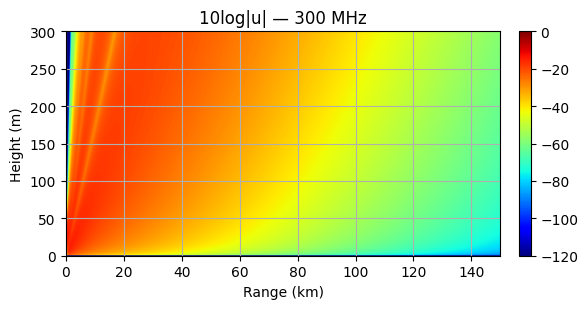

In [6]:
def plot_field_2d(field, title='', vmin=-120, vmax=0, x_mult=1e-3):
    """Plot 2D field distribution in dB."""
    data = 10 * np.log10(np.abs(field.field) + 1e-16).real
    extent = [field.x_grid[0]*x_mult, field.x_grid[-1]*x_mult,
              field.z_grid[0], field.z_grid[-1]]
    plt.figure(figsize=(6, 3.2))
    plt.imshow(data.T[::-1, :], extent=extent, norm=Normalize(vmin, vmax),
               aspect='auto', cmap='jet')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xlabel('Range (km)')
    plt.ylabel('Height (m)')
    plt.tight_layout()
    plt.grid(True)
    plt.show()

plot_field_2d(field_300, '10log|u| — 300 MHz')

## 3 GHz propagation

In [7]:
src_3g = RWPGaussSourceModel(
    freq_hz=3e9,
    height_m=30,
    beam_width_deg=2,
    elevation_angle_deg=0,
)

field_3g = rwp_forward_task(src_3g, env, params)

k_min: 62.85195926477884, k_max: 62.854917914272086
rational_approx_order: (5, 6), beta: 62.827425088618, dx: 25.0, dz: 0.03125


### Horizontal field slice at 30 m height

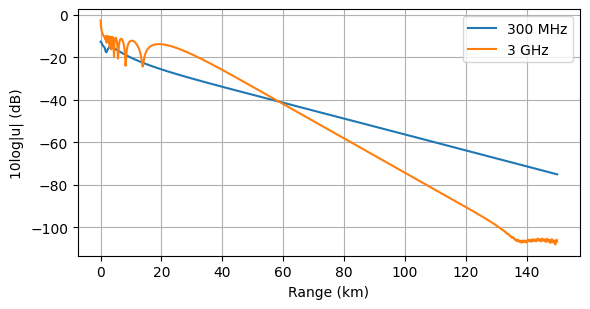

In [8]:
def plot_horizontal(fields, labels, z0=30, x_mult=1e-3):
    """Plot horizontal field slice at height z0."""
    plt.figure(figsize=(6, 3.2))
    for field, label in zip(fields, labels):
        z_idx = np.argmin(np.abs(field.z_grid - z0))
        data = 10 * np.log10(np.abs(field.field[:, z_idx]) + 1e-16).real
        plt.plot(field.x_grid * x_mult, data, label=label)
    plt.xlabel('Range (km)')
    plt.ylabel('10log|u| (dB)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_horizontal([field_300, field_3g], ['300 MHz', '3 GHz'])

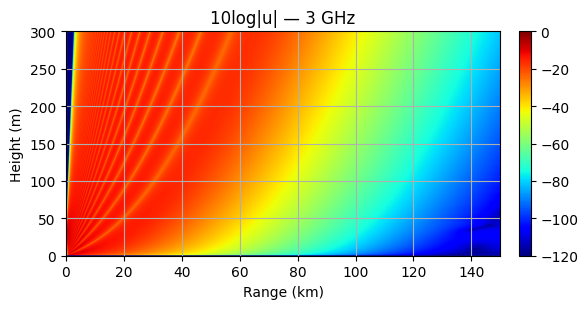

In [9]:
plot_field_2d(field_3g, '10log|u| — 3 GHz')